<div style="background: linear-gradient(125deg, #080b12 0%, #151b2c 58%, #4b102d 100%); border: 1px solid #343b52; border-radius: 18px; padding: 30px 34px; margin: 4px 0 26px; color: #ffffff; box-shadow: 0 12px 30px rgba(0,0,0,0.22);">
  <div style="font-size: 14px; font-weight: 700; letter-spacing: 0.16em; color: #ff5a5f; text-transform: uppercase;">AMD × vLLM Semantic Router Workshop</div>
  <div style="font-size: 38px; line-height: 1.15; font-weight: 800; margin-top: 10px;">Route One Agent Across Two Models</div>
  <div style="font-size: 18px; color: #d7dbea; margin-top: 8px;">Build one stable application endpoint that chooses the right model for each request.</div>
  <div style="display: flex; flex-wrap: wrap; align-items: stretch; gap: 10px; margin-top: 24px;">
    <div style="flex: 1 1 145px; background: rgba(255,255,255,0.08); border-radius: 10px; padding: 13px 16px;"><div style="font-size: 11px; letter-spacing: 0.12em; color: #aeb6cc;">APPLICATION</div><div style="font-size: 18px; font-weight: 700; margin-top: 4px;">One agent</div></div>
    <div style="display: flex; align-items: center; color: #ff5a5f; font-size: 24px; font-weight: 700;">→</div>
    <div style="flex: 1 1 190px; background: rgba(255,90,95,0.14); border: 1px solid rgba(255,90,95,0.4); border-radius: 10px; padding: 13px 16px;"><div style="font-size: 11px; letter-spacing: 0.12em; color: #ffadb0;">STABLE ENDPOINT</div><div style="font-size: 18px; font-weight: 700; margin-top: 4px;">vllm-sr/auto</div></div>
    <div style="display: flex; align-items: center; color: #72d6ff; font-size: 24px; font-weight: 700;">→</div>
    <div style="flex: 1 1 190px; background: rgba(114,214,255,0.10); border-radius: 10px; padding: 13px 16px;"><div style="font-size: 11px; letter-spacing: 0.12em; color: #9ee4ff;">MODEL PATHS</div><div style="font-size: 16px; font-weight: 700; margin-top: 4px;">Routine model<br>Reasoning model</div></div>
  </div>
  <div style="margin-top: 18px; font-size: 13px; color: #aeb6cc;">AMD Instinct GPU · vLLM · Semantic Router · Hermes Agent</div>
</div>

**One agent. One endpoint. Two model paths.**

Most applications begin with one model endpoint. That is simple, but every
request pays for the same model, even when some requests are quick and others
need deeper reasoning.

In this workshop, you will put one stable endpoint in front of two models and
teach it when to use each one. You will try the route in a browser, call it
through an API, connect an agent, inspect why a decision happened, and create a
policy for your own application.

The path we will build is:

```text
application need → observable signal → routing decision → selected model
```


## 1. Launch Two Model Endpoints on an AMD GPU

The first model handles direct, interactive work. The second is reserved for
requests that benefit from deeper reasoning.

| Model path | Intended work |
| --- | --- |
| Routine model | Definitions, summaries, and direct instructions |
| Reasoning model | Diagnosis, comparison, planning, and multi-step analysis |

Open the Jupyter launcher with the **+** button. You will need two terminals,
one for each vLLM server.


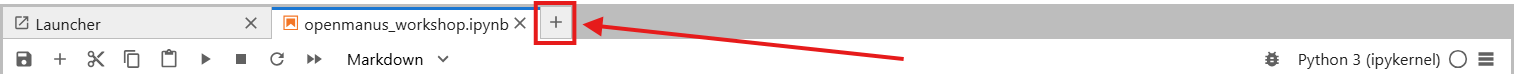


Choose **Terminal** twice from the launcher. Keep both terminal tabs
open: each one will run a model server in the foreground.


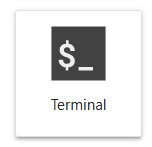


Run the routine model in the first terminal:

```bash
vllm serve google/gemma-4-12B-it   --host 0.0.0.0   --port 8002   --served-model-name gemma-4-12b   --gpu-memory-utilization 0.45   --max-model-len 65536   --kv-cache-dtype fp8   --max-num-seqs 16   --enable-auto-tool-choice   --tool-call-parser gemma4
```

Run the reasoning model in the second terminal:

```bash
vllm serve Qwen/Qwen3.8-27B-FP8   --host 0.0.0.0   --port 8001   --served-model-name qwen3.8-27b   --gpu-memory-utilization 0.47   --max-model-len 65536   --kv-cache-dtype fp8   --max-num-seqs 16   --enforce-eager   --reasoning-parser qwen3   --enable-auto-tool-choice   --tool-call-parser qwen3_xml
```

These are standard `vllm serve` commands. The image already supplies the model
cache and ROCm environment, so the details worth noticing are the model names,
ports, context lengths, and GPU-memory allocations.

Wait until both terminals report that their servers are ready, then return to
the notebook.


### Start vLLM Semantic Router and Verify Services

Load the workshop helper after both model servers are ready. The first code
cell starts the prebuilt Router, Envoy, and Dashboard, then reports the status
of the complete workshop environment.


In [ ]:
import importlib
import workshop_lab

importlib.reload(workshop_lab)
lab = workshop_lab.lab
lab.welcome()
services = lab.start_platform()
services = lab.status()


In [ ]:
models = lab.show_models()

if models["routine"] and models["reasoning"]:
    print("Both model servers are ready.")
else:
    print("Start the missing model server, then run this cell again.")


Send one request directly to each model. This establishes a useful
baseline: both backends work before the router enters the path.


In [ ]:
if models["routine"]:
    routine_backend_result = lab.direct_model_check("routine")
else:
    routine_backend_result = None
    print("Skipped until the routine model is running.")


In [ ]:
if models["reasoning"]:
    reasoning_backend_result = lab.direct_model_check("reasoning")
else:
    reasoning_backend_result = None
    print("Skipped until the reasoning model is running.")


## 2. Set Up vLLM Semantic Router with Two Models

An application should not have to choose a model before every request. We will
give it one OpenAI-compatible endpoint:

```text
application → Envoy → Semantic Router → selected vLLM server
                              │
                              └── decision evidence → Dashboard
```

The setup cell in Section 1 already started a prebuilt two-model routing policy
so you can experience the system before studying its YAML. In Section 7, you
will rebuild this configuration one part at a time.

`lab.start_platform()` runs `/opt/workshop/bin/start-platform.sh`. The
script loads `/opt/workshop/config/router-demo.yaml`, starts the Router,
Envoy, and Dashboard, and waits until they are ready.


## 3. vLLM Semantic Router Dashboard Demo

Open the Dashboard, then go to **Playground** and select `vllm-sr/auto`.


In [ ]:
lab.browser_links()


Start with a request that should be routine:

> Give me a one-sentence definition of HTTP.

Before you send it, predict the model. After it completes, record the selected
decision, model, and latency.

Now try a request designed to match our reasoning policy:

> Diagnose cascading failures in a distributed queue, compare multiple
> remediation strategies and their tradeoffs, and justify a safe rollout plan.

Predict again and send it. Then select **Build → Outcomes → Insights**.
Under **Insight Records**, find the two newest requests in the **Routing
Insights** table. Open each record to see the evidence used by the router,
not just the model’s answer.


### See the Complexity Policy the Router Is Using

The prebuilt policy comes from:

```text
/opt/workshop/config/router-demo.yaml
```

When the platform starts, that file is copied to the active configuration:

```text
/workspace/generated-config/router.yaml
```

The complexity definition is stored at
`routing.signals.complexity[0]`. Run the next cell to read the actual active
configuration rather than a separate example.


In [ ]:
from pathlib import Path
import yaml

active_config_path = Path("/workspace/generated-config/router.yaml")
active_config = yaml.safe_load(
    active_config_path.read_text(encoding="utf-8")
)
active_complexity_signal = active_config["routing"]["signals"]["complexity"][0]

print(f"Read from: {active_config_path}")
print()
print(yaml.safe_dump(
    {"complexity": [active_complexity_signal]},
    sort_keys=False,
))


### How Those Examples Become a Route

The `hard.candidates` and `easy.candidates` are semantic examples, not exact
keywords. The complexity signal compares the request with both groups and
produces a hard score and an easy score.

```text
margin = hard score - easy score

margin >  0.10  -> hard
margin < -0.10  -> easy
otherwise       -> medium
```

The threshold controls the uncertain `medium` region. It is not a minimum
similarity score.

The active reasoning decision contains this condition:

```yaml
- type: complexity
  name: request_complexity:hard
```

A signal asks a question about the request. A condition refers to one named
answer. Only the `hard` answer makes the reasoning lane eligible. Easy and
medium requests continue to the routine fallback.


## 4. Test Routing Through the Application API

This is a prediction exercise with a scorecard.

The Dashboard showed that routing works. Now call the same OpenAI-compatible
endpoint from Python and compare the observed route with your prediction.

Keep the known routine prompt as a control, then replace the three placeholders
below:

1. a request you expect the routine model to handle;
2. a request you expect the reasoning model to handle; and
3. a request whose route you genuinely cannot predict.

Write down each prediction first. Every result shows the measured complexity,
winning decision, and selected model.


In [ ]:
routing_experiment = [
    {
        "label": "control",
        "prompt": "Give me a short definition of HTTP.",
        "prediction": "routine",
    },
    {
        "label": "my clearly routine prompt",
        "prompt": "YOUR ROUTINE PROMPT HERE",
        "prediction": "routine",
    },
    {
        "label": "my clearly hard prompt",
        "prompt": "YOUR HARD PROMPT HERE",
        "prediction": "reasoning",
    },
    {
        "label": "my uncertain prompt",
        "prompt": "YOUR AMBIGUOUS PROMPT HERE",
        "prediction": "uncertain",
    },
]

routing_experiment


In [ ]:
if any("YOUR " in item["prompt"] for item in routing_experiment):
    print("Replace the three YOUR ... placeholders, predict the routes, then rerun.")
    routing_results = []
else:
    routing_results = lab.compare_predictions(routing_experiment)


For each result, compare:

- `prediction`: what you expected;
- `observed_complexity`: what the signal measured;
- `observed_decision`: which policy matched; and
- `observed_model`: where the request was sent.

If you see `medium`, the request landed between the easy and hard examples.
Keep that prompt. Cases like it are useful when you tune the policy.

### Improve the Router from What You Observed

Use the result that surprised you most as calibration evidence:

- If similar prompts receive inconsistent complexity results, improve the
  easy and hard candidate examples.
- If too many well-separated prompts land in `medium`, review the examples
  first and then adjust the threshold.
- If complexity is correct but the route is wrong for your application, add
  another condition instead of trying to force complexity to represent a
  different fact.

If complexity is not enough, vLLM Semantic Router provides other
[signal types](https://vllm-sr.ai/docs/tutorials/signal/overview) for
application-specific facts:

| Application fact | Useful signal type |
| --- | --- |
| An exact incident or business marker appears | `keyword` |
| The request is too large for one model | `context` |
| The application labels the workload | `metadata` |
| The request contains personal information | `pii` |
| The request includes an image or audio | `input_modality` |
| The conversation is multi-turn or tool-heavy | `conversation` |

A practical policy may combine them:

```text
hard AND public                 -> reasoning model
PII OR confidential marker      -> local model
hard AND NOT private            -> cloud-eligible model
```

Use `AND` when every requirement must hold, `OR` when any trigger should use
the same route, and `NOT` for an explicit exclusion.

There is no target number of conditions. Start with the smallest rule that
expresses the requirement clearly, then add a condition only when the route
needs another independent fact. In Section 7 you will build the complexity
signal and connect it to a decision. In Section 8 you will add a second signal
and observe how priority resolves two matching decisions.


## 5. Connect Hermes Agent to vLLM Semantic Router

This section checks one application integration:

```text
Can Hermes use vllm-sr/auto, edit a project, and finish with passing tests?
```

Hermes knows only the model name `vllm-sr/auto`. It does not know which
backend model serves the request.

Before running it, open the visible `agent-demo/` folder beside this
notebook. `pricing.py` contains the duplicated logic, `reporting.py` uses the
public functions, and `test_pricing.py` defines the behavior that must remain
unchanged.

This run succeeds when Hermes completes the edit and the tests pass. Section 6
demonstrates model changes across several user turns.


In [ ]:
AGENT_TASK = (
    "Read this small project, identify the duplicated pricing logic, extract "
    "it into one private helper without changing public behavior, and run "
    "python -m pytest -q."
)

exercise_dir = lab.prepare_agent_demo()
print("Task Hermes will receive:")
print(AGENT_TASK)


The setup cell copied the visible `agent-demo/` project into a clean working
directory. Hermes edits the copy, so the original files remain available for
comparison. Run the next cell and wait for:

```text
Hermes final response
3 passed
```

The progress timer confirms that the agent is still running. You do not need
to watch the Dashboard during this step.


In [ ]:
agent_run = lab.run_agent(AGENT_TASK, exercise_dir)


### Verify the Hermes Agent Workflow

The final response describes the change, and `3 passed` verifies the edited
project.

```text
Hermes → vllm-sr/auto → selected backend → file edit → passing tests
```

The integration stays the same as the routing policy grows. Hermes continues
to call `vllm-sr/auto`; conditions for context length, conversation shape,
private data, or application metadata belong in the Router configuration,
not in the agent.

Inspecting internal model calls is optional.

To inspect them, select **Build → Outcomes → Insights** and look under
**Insight Records → Routing Insights**.


## 6. vLLM Semantic Router Multi-Turn Simulation

Now test routing behavior directly, without the agent harness in the middle.
The next cell sends four user turns through one conversation:

1. define a technical term;
2. rewrite one sentence;
3. compare several coding strategies; and
4. summarize the recommendation.

Predict the model for each turn before running the cell. Every result prints
the latest user message, complexity class, decision, and selected model.


In [ ]:
conversation = []
turn_results = []

turns = [
    "Define idempotency in one sentence.",
    "Rewrite this sentence clearly: retries can make the same job run twice.",
    (
        "Compare multiple refactoring strategies for the duplicated pricing logic, "
        "explain their tradeoffs, and justify a safe implementation plan."
    ),
    "Summarize your recommendation in one sentence.",
]

for prompt in turns:
    conversation, observed = lab.routed_turn(conversation, prompt)
    turn_results.append(observed)


Read `turn_results` from top to bottom.

The comparison request should be the clearest reasoning candidate. The direct
requests should use the routine path or land in the medium band and fall back
to it.

If a result differs from your prediction, keep that prompt for the calibration
exercise. The mismatch tells you where the policy examples or threshold need
work.


## 7. Build the vLLM Semantic Router Configuration

You have used a prebuilt route from the Dashboard, Python, and Hermes. Now
rebuild the same routing pattern from the smallest useful configuration.

To configure vLLM Semantic Router, you create a YAML policy. The repository
contains
many complete [configuration examples](https://github.com/vllm-project/semantic-router/tree/main/config),
but this section builds the smallest useful policy one layer at a time.

The basic customization loop is:

```text
define a signal
→ reference that signal from a decision
→ assign eligible models
→ test the observed route
```

The [signal guide](https://vllm-sr.ai/docs/tutorials/signal/overview)
describes the available observations. Adding a signal definition alone does
not change routing. A new signal takes effect only after a decision references
it directly or through a projection.
Decision rules combine their conditions with `AND`, `OR`, or `NOT`, as shown
in the [decision configuration guide](https://vllm-sr.ai/docs/tutorials/decision/overview#configuration).

| Stage | What you build | Question it answers |
| --- | --- | --- |
| 1 | One model and a fallback decision | Where does unmatched traffic go? |
| 2 | A second model path | Which backends are available? |
| 3 | A complexity signal | What did the Router observe? |
| 4 | A reasoning decision | What should happen when the signal matches? |

Every stage writes a complete YAML file under `generated-config/` beside the
notebook. The important configuration areas are:

| Configuration area | Purpose |
| --- | --- |
| `listeners` | Defines where application requests enter |
| `providers.models` | Connects logical model names to vLLM endpoints |
| `routing.modelCards` | Describes model capabilities such as context size |
| `routing.signals` | Extracts evidence from each request |
| `routing.decisions` | Converts evidence into an eligible model path |
| `priority` | Resolves cases where several decisions match |
| `algorithm` | Selects among models assigned to a decision |
| `global.router.auto_model_names` | Exposes the stable application-facing name |

Focus on the highlighted fields at each stage. Configuration validation and
runtime startup checks are handled by `lab.validate_config()`.


### Stage 1: Define the Routine Model and Fallback

```text
application → vllm-sr/auto → routine-model
```

Pay attention to these fields:

- `listeners`: the routed API address, port, and request timeout;
- `providers.models`: the logical model name and its vLLM backend endpoint;
- `provider_model_id`: the model name expected by the vLLM server;
- `routing.modelCards`: the model's modality and context capacity;
- `global.router.auto_model_names`: the stable name applications request; and
- `routine-lane`: the fallback decision for every unmatched request.


In [ ]:
from pathlib import Path
import yaml

NOTEBOOK_DIR = Path(workshop_lab.__file__).resolve().parent
CONFIG_DIR = NOTEBOOK_DIR / "generated-config"
CONFIG_DIR.mkdir(exist_ok=True)

stage1_yaml = '''
version: v0.3

listeners:
  - name: workshop
    address: 0.0.0.0
    port: 8898
    timeout: 600s

providers:
  models:
    - name: routine-model
      api_format: openai
      provider_model_id: gemma-4-12b
      backend_refs:
        - name: routine-backend
          endpoint: 127.0.0.1:8002
          protocol: http
          weight: 1

routing:
  modelCards:
    - name: routine-model
      modality: text
      context_window_size: 65536
  signals: {}
  decisions:
    - name: routine-lane
      description: Send every request to the routine model.
      priority: 100
      rules:
        operator: AND
        conditions: []
      modelRefs:
        - model: routine-model
      algorithm:
        type: static

global:
  router:
    auto_model_names:
      - vllm-sr/auto
  stores:
    response_cache:
      enabled: false
'''

stage1_path = CONFIG_DIR / "01-one-model.yaml"
stage1_path.write_text(stage1_yaml.strip() + "\n", encoding="utf-8")

print("Saved the complete one-model configuration to:")
print(stage1_path)
print()
print(stage1_path.read_text(encoding="utf-8"))

lab.validate_config(stage1_path)


### What Stage 1 Establishes

The fallback contains:

```yaml
operator: AND
conditions: []
```

An `AND` rule succeeds when every condition succeeds. With no conditions,
there is nothing to reject, so this decision matches every request.

Also notice:

- `modelRefs` assigns `routine-model` to this decision;
- `priority: 100` gives later, more specific rules room to override it; and
- `algorithm.type: static` directly selects the assigned model.

The generated file is an artifact, not the active configuration. A later stage
will be reviewed and deployed through the Dashboard.


### Stage 2: Add the Reasoning Model

```text
                                  ┌──► routine-model
application → vllm-sr/auto ───────┤
                                  └──► reasoning-model
```

Pay attention to the two objects added together:

- the provider entry defines how to reach the vLLM endpoint;
- the model card describes the model to the routing policy;
- both use the same logical name, `reasoning-model`;
- `provider_model_id` must match the name served by vLLM; and
- `context_window_size` must not exceed the backend's actual capacity.

This stage connects the model but does not make it eligible for any request.


In [ ]:
stage2 = yaml.safe_load(stage1_path.read_text(encoding="utf-8"))

reasoning_provider = {
    "name": "reasoning-model",
    "api_format": "openai",
    "provider_model_id": "qwen3.8-27b",
    "backend_refs": [
        {
            "name": "reasoning-backend",
            "endpoint": "127.0.0.1:8001",
            "protocol": "http",
            "weight": 1,
        }
    ],
}
reasoning_card = {
    "name": "reasoning-model",
    "modality": "text",
    "context_window_size": 65536,
}

stage2["providers"]["models"].append(reasoning_provider)
stage2["routing"]["modelCards"].append(reasoning_card)

stage2_path = CONFIG_DIR / "02-two-models.yaml"
stage2_path.write_text(
    yaml.safe_dump(stage2, sort_keys=False),
    encoding="utf-8",
)

print("Added these two objects:")
print(yaml.safe_dump(
    {
        "provider_model": reasoning_provider,
        "model_card": reasoning_card,
    },
    sort_keys=False,
))
print("Saved the complete configuration to:")
print(stage2_path)
lab.validate_config(stage2_path)


### What Stage 2 Changes

Both easy and difficult prompts still follow the fallback.

The new model is reachable, but no decision refers to it:

```text
connected model ≠ selectable route
```

A decision must make `reasoning-model` eligible for a request.


### Stage 3: Add the Complexity Signal

The router needs evidence before it can make a semantic choice. A **signal**
extracts that evidence.

Pay attention to:

- `name`: the stable identifier decisions will reference;
- `hard.candidates`: examples of work that should escalate;
- `easy.candidates`: examples of work that should stay routine; and
- `threshold`: the size of the uncertain `medium` band.

The signal reports one of:

```text
request_complexity:easy
request_complexity:medium
request_complexity:hard
```


In [ ]:
stage3 = yaml.safe_load(stage2_path.read_text(encoding="utf-8"))

complexity_signal = {
    "name": "request_complexity",
    "threshold": 0.10,
    "description": "Separate direct requests from reasoning-heavy work.",
    "hard": {
        "candidates": [
            "diagnose cascading failures in a distributed system",
            "compare multiple remediation strategies and their tradeoffs",
            "analyze a root cause and justify a safe rollout plan",
            "investigate a complex production failure from incomplete evidence",
            "solve a multi-step system design problem",
        ]
    },
    "easy": {
        "candidates": [
            "define a technical term in one sentence",
            "summarize a short passage briefly",
            "rewrite a sentence without analysis",
        ]
    },
}

stage3["routing"]["signals"]["complexity"] = [complexity_signal]

stage3_path = CONFIG_DIR / "03-add-signal.yaml"
stage3_path.write_text(
    yaml.safe_dump(stage3, sort_keys=False),
    encoding="utf-8",
)

print("Added this signal:")
print(yaml.safe_dump(
    {"complexity": [complexity_signal]},
    sort_keys=False,
))
print("Saved the complete configuration to:")
print(stage3_path)
lab.validate_config(stage3_path)


The new signal measures complexity, but requests still follow the
fallback because no decision uses that measurement yet.

For this signal, `threshold` controls the size of the uncertain region:

```text
margin = hard_score - easy_score

margin >  threshold  → hard
margin < -threshold  → easy
otherwise            → medium
```

With `threshold: 0.10`, margins from `-0.10` through `+0.10` are medium.

Tune in this order:

1. collect prompts that represent your application;
2. label the route you want for each prompt;
3. improve the hard and easy candidate examples; and
4. adjust the threshold only if the candidates separate well but the medium
   band is too wide or too narrow.

Under-routing may reduce answer quality. Over-routing consumes more latency
and accelerator capacity. Your application determines which error costs more.

After the final policy is deployed, send labelled prompts from
**Dashboard → Playground** and open their records under
**Build → Outcomes → Insights**. The record's signal values show the hard
score, easy score, and margin used for calibration.


### Stage 4: Route Hard Prompts to the Reasoning Model

The policy is now:

```text
if request_complexity is hard:
    use reasoning-model
otherwise:
    use routine-model
```

Pay attention to:

- `conditions.type: complexity`, which selects the signal family;
- `conditions.name: request_complexity:hard`, which selects one signal result;
- `priority: 200`, which beats the fallback's priority of 100;
- `modelRefs`, which assigns `reasoning-model`; and
- `algorithm.type: static`, which selects that assigned model directly.


In [ ]:
stage4 = yaml.safe_load(stage3_path.read_text(encoding="utf-8"))

reasoning_decision = {
    "name": "reasoning-lane",
    "description": "Use the stronger model for difficult work.",
    "priority": 200,
    "rules": {
        "operator": "AND",
        "conditions": [
            {
                "type": "complexity",
                "name": "request_complexity:hard",
            }
        ],
    },
    "modelRefs": [
        {
            "model": "reasoning-model",
            "use_reasoning": True,
        }
    ],
    "algorithm": {"type": "static"},
}

stage4["routing"]["decisions"].insert(0, reasoning_decision)

stage4_path = CONFIG_DIR / "04-add-decision.yaml"
stage4_path.write_text(
    yaml.safe_dump(stage4, sort_keys=False),
    encoding="utf-8",
)

print("Added this higher-priority decision:")
print(yaml.safe_dump(reasoning_decision, sort_keys=False))
print("Saved the complete configuration to:")
print(stage4_path)
lab.validate_config(stage4_path)


Trace one hard request through the completed policy:

```text
1. request_complexity reports hard
2. reasoning-lane matches
3. routine-lane also matches because it is the fallback
4. priority 200 beats priority 100
5. the static algorithm selects reasoning-model
```

Now each configuration concept names something visible in that trace:

| Concept | What you can observe |
| --- | --- |
| Signal | `request_complexity:hard` |
| Decision | `reasoning-lane` matched |
| Priority | `200` won over fallback `100` |
| Algorithm | `static` selected the assigned path |
| Model | `reasoning-model` served the request |


## 8. Add an Application-Specific Routing Rule

Imagine an incident-response assistant. Difficult diagnosis normally belongs
on the reasoning model, but a request marked as an active production incident
must receive a fast acknowledgement first.

Write the application requirement before writing YAML:

> When an active-incident marker appears, use the routine model immediately,
> even if the request also looks reasoning-heavy.

The new configuration adds:

```text
keyword signal  active-incident
decision        incident-fast-lane
priority        300, higher than reasoning-lane at 200
modelRefs       routine-model
```

The matching `signal.name` and `condition.name` connect the observed keyword to
the decision. The next cell writes one participant-facing file:

```text
generated-config/05-incident-policy.yaml
```

It contains only the routing policy, so Dashboard can apply the new model
cards, signals, and decisions without overwriting environment-specific
listeners, providers, storage, or service settings. The complete
configuration used for validation is kept in a hidden internal directory.

Notice that two different operators appear in this example:

- `operator: OR` inside the keyword signal means any listed phrase can make
  that one signal match.
- `operator: AND` inside the decision combines named signal conditions. With
  one condition it simply requires `active-incident` to match.

Signal operators combine observations inside one detector. Decision operators
combine the named facts used to decide whether a route is eligible.


### Import and Deploy the Updated Configuration

1. Run the next cell to generate `05-incident-policy.yaml`.
2. Open the file from `generated-config/` in Jupyter.
3. Copy the complete contents of `05-incident-policy.yaml`.
4. Open **Build → Routing → Builder** in the Dashboard.
5. Select **Import**, paste the YAML, and select **Import** again.
6. Select **Compile**.
7. Confirm that `incident-fast-lane` has priority 300 and selects
   `routine-model`.
8. Select **Deploy**.
9. Return to the notebook and run the collision test.

Importing `05-incident-policy.yaml` loads the policy into Builder.
Selecting **Deploy** makes it active in the running router.


In [ ]:
stage5 = yaml.safe_load(stage4_path.read_text(encoding="utf-8"))

incident_signal = {
    "name": "active-incident",
    "operator": "OR",
    "keywords": [
        "SEV-1",
        "production outage",
        "service unavailable",
    ],
    "case_sensitive": False,
}
incident_decision = {
    "name": "incident-fast-lane",
    "description": "Use the low-latency model during an active incident.",
    "priority": 300,
    "rules": {
        "operator": "AND",
        "conditions": [
            {
                "type": "keyword",
                "name": "active-incident",
            }
        ],
    },
    "modelRefs": [{"model": "routine-model"}],
    "algorithm": {"type": "static"},
}

stage5["routing"]["signals"]["keywords"] = [incident_signal]
stage5["routing"]["decisions"].insert(0, incident_decision)

validation_dir = CONFIG_DIR / ".validation"
validation_dir.mkdir(exist_ok=True)
stage5_validation_path = validation_dir / "05-incident-policy.yaml"
stage5_validation_path.write_text(
    yaml.safe_dump(stage5, sort_keys=False),
    encoding="utf-8",
)
stage5_path = CONFIG_DIR / "05-incident-policy.yaml"
stage5_path.write_text(
    yaml.safe_dump({"routing": stage5["routing"]}, sort_keys=False),
    encoding="utf-8",
)

print("Dashboard-equivalent signal:")
print(yaml.safe_dump(incident_signal, sort_keys=False))
print("Dashboard-equivalent decision:")
print(yaml.safe_dump(incident_decision, sort_keys=False))
lab.validate_config(stage5_validation_path)
print("Saved the Dashboard policy to:")
print(stage5_path)


### Verify Priority When Both Rules Match

Consider:

> SEV-1 production outage. Diagnose the root cause, compare multiple
> remediation strategies, and recommend a rollout.

This request contains the incident keyword and asks for difficult analysis.
Both `incident-fast-lane` and `reasoning-lane` can match.

Predict the winner, deploy `05-incident-policy.yaml`, and run the next cell.
The verification checks that priority 300 selects `incident-fast-lane` and
`routine-model`.


In [ ]:
COLLISION_PROMPT = (
    "SEV-1 production outage. Diagnose the root cause, compare three "
    "remediation plans, and recommend a rollout."
)

if not lab.decision_is_active("incident-fast-lane"):
    print("The incident policy is not active yet.")
    print("1. Open generated-config/05-incident-policy.yaml in Jupyter.")
    print("2. Copy the complete contents of 05-incident-policy.yaml.")
    print("3. In Dashboard, select Build → Routing → Builder → Import.")
    print("4. Paste, Import, Compile, and Deploy.")
    print("5. Rerun this cell.")
    print("Active decisions:", lab.active_decisions())
    incident_result = None
else:
    incident_result = lab.routed_chat(COLLISION_PROMPT, max_tokens=100)
    assert incident_result["decision"] == "incident-fast-lane"
    assert incident_result["selected_model"] == "routine-model"
    print(
        "✓ Collision resolved by priority: "
        "incident-fast-lane → routine-model"
    )


## 9. Introduce Select-Mode Mixture of Models

You now have:

```text
one stable application-facing model name
+ separately deployed models with different strengths
+ a policy that chooses how to fulfill each request
= Select-mode Mixture of Models
```

This is different from Mixture of Experts. MoE routes among components inside
one model; MoM coordinates separate model deployments.

Today you built **Select** mode: one request selects one model. A follow-up
workshop can build on the same entrypoint with:

| Mode | Behavior |
| --- | --- |
| Cascade | Start with one model and escalate when needed |
| Fusion | Ask multiple models and synthesize their outputs |
| Workflow | Assign planner, worker, and verifier roles |


## 10. Challenge: Keep Private Finance Requests Local

Imagine that `vllm-sr/auto` belongs to a financial assistant. For this
exercise:

| Model | Application role |
| --- | --- |
| `routine-model` | Smaller model inside the local data boundary |
| `reasoning-model` | Larger model treated as an external service |

Both models are physically local in this workshop. The different roles
simulate a real deployment boundary.

Your goal is to preserve useful routing for public requests while ensuring
that the private financial prompts in the scorecard stay on the smaller local
model.

### Dashboard Hints

1. Add a signal from **Dashboard → Build → Routing → Signals**.
2. Open **Dashboard → Build → Routing → Decisions**. Either edit an existing
   decision or select **Add Decision**.
3. In the decision rules, select **Add Condition** and choose the rule shape
   that expresses your intent:

| Desired behavior | Rule shape |
| --- | --- |
| Invoke the decision when the signal matches | Add `Signal condition` under the decision's `AND group` |
| Exclude the decision when the signal matches | Add `NOT group` under the `AND group`, then put `Signal condition` inside it |

4. For the **Signal condition**, set **Signal Type** to the type you created
   and set **Signal Name** to the exact name of your signal.
5. Select **Save**. A `NOT group` wraps the one condition it reverses, so place
   the signal condition inside that group when you want an exclusion.
6. Infer the signal details and the appropriate decision from the four test
   prompts.

Compile and deploy your policy, then run the scorecard without changing its
expected results. To claim the workshop prize, show the presenter a passing
test cell.


In [ ]:
challenge_prompts = {
    "public_simple": "Define operating margin in one sentence.",
    "public_hard": (
        "Compare multiple strategies for reducing a working-capital "
        "shortfall, explain their tradeoffs, and justify a safe rollout plan."
    ),
    "private_simple": (
        "PRIVATE ACCOUNT-ID 4821: summarize this payment note in one "
        "sentence: invoice is 12 days overdue."
    ),
    "private_hard": (
        "PRIVATE ACCOUNT-ID 4821: compare multiple restructuring "
        "strategies, explain their tradeoffs, and justify a safe rollout plan."
    ),
}

for name, prompt in challenge_prompts.items():
    print(f"{name}: {prompt}")


Before running the scorecard, predict which model should handle each request.

| Request | Required model behavior |
| --- | --- |
| Public simple | Smaller local model |
| Public hard | Larger reasoning model |
| Private simple | Smaller local model |
| Private hard | Smaller local model |

More than one valid Router policy can satisfy this requirement. The scorecard
checks behavior rather than requiring one specific signal name, decision name,
or rule-tree design.


In [ ]:
CHALLENGE_EXPECTED_MODELS = {
    "public_simple": "routine-model",
    "public_hard": "reasoning-model",
    "private_simple": "routine-model",
    "private_hard": "routine-model",
}

challenge_results = {
    name: lab.routed_chat(prompt, max_tokens=80)
    for name, prompt in challenge_prompts.items()
}

failures = []
for name, expected_model in CHALLENGE_EXPECTED_MODELS.items():
    observed = challenge_results[name]
    actual_model = observed["selected_model"]
    marker = "✓" if actual_model == expected_model else "✗"
    print(
        f"{marker} {name}: {observed['decision']} → {actual_model} "
        f"(expected model {expected_model})"
    )
    if actual_model != expected_model:
        failures.append(
            f"{name}: observed {actual_model}, expected {expected_model}"
        )

assert not failures, "Challenge checks failed:\n" + "\n".join(failures)
print()
print("Challenge complete: 4/4 routing checks passed")


You have finished the challenge only when the notebook prints:

```text
Challenge complete: 4/4 routing checks passed
```

Show the passing cell to the presenter to claim the workshop prize. Then open
the four records under **Build → Outcomes → Insights** and explain why each
request selected its model.

A production privacy policy needs stronger controls than the simple markers
used in this exercise. This challenge demonstrates the routing structure that
the future
financial-data workshop will extend with PII detection and data-boundary
verification.


## Workshop Summary

You began with two independent model endpoints. You now have one stable model
name and a policy that can choose between them.

You can:

- connect model paths without changing the application-facing endpoint;
- define evidence with signals;
- turn that evidence into decisions;
- resolve overlapping rules with priority;
- inspect the reason for an individual route;
- connect Hermes Agent through the same endpoint; and
- test a routing policy against prompts from your own workload.

The next workshop can keep this interface and move from selecting one model to
coordinating several.
